# Exploratory Data Analysis

In [14]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import librosa
from tqdm import tqdm

### Missing Species

Identify the species in train_soundscapes_labels.csv and not in the train.csv

In [2]:
# 1. Load Data
taxonomy = pd.read_csv('../../data/taxonomy.csv')
train = pd.read_csv('../../data/train.csv')

# 2. Get all unique species from taxonomy (the 234 targets)
all_target_species = set(taxonomy['primary_label'].unique())

# 3. Get species present as Primary
primary_species = set(train['primary_label'].unique())

# 4. Get species present as Secondary
# (Secondary labels are strings like "['bird1', 'bird2']", so we convert to list)
def get_secondary_set(df):
    all_secondary = []
    for item in df['secondary_labels']:
        # Convert string representation of list to actual list
        birds = ast.literal_eval(item)
        all_secondary.extend(birds)
    return set(all_secondary)

secondary_species = get_secondary_set(train)

# 5. The Real Audit
combined_train_species = primary_species.union(secondary_species)
truly_missing = all_target_species - combined_train_species

print(f"Total target species: {len(all_target_species)}")
print(f"Species present as Primary: {len(primary_species)}")
print(f"Species present ONLY as Secondary: {len(secondary_species - primary_species)}")
print(f"Species TRULY missing from train.csv: {len(truly_missing)}")
print(f"The 'Ghost' List: {list(truly_missing)}")

Total target species: 234
Species present as Primary: 206
Species present ONLY as Secondary: 0
Species TRULY missing from train.csv: 28
The 'Ghost' List: ['25073', '47158son12', '47158son14', '47158son03', '47158son21', '1491113', '47158son08', '47158son23', '47158son10', '47158son06', '47158son07', '47158son25', '47158son16', '517063', '47158son17', '47158son15', '47158son19', '47158son04', '47158son18', '47158son09', '47158son05', '47158son22', '47158son02', '47158son20', '47158son13', '47158son24', '47158son01', '47158son11']


Check if these missing species are present in the expert-labeled soundscape segments.

In [4]:
# Load the soundscape labels
ss_labels = pd.read_csv('../../data/train_soundscapes_labels.csv').drop_duplicates()

# Check how many of our missing species are here
available_in_ss = ss_labels[ss_labels['primary_label'].isin(truly_missing)]
print(f"Missing species found in soundscapes: {available_in_ss['primary_label'].unique()}")

Missing species found in soundscapes: <StringArray>
['517063', '1491113']
Length: 2, dtype: str


### Class Distribution 

=== FINAL SPECIES FREQUENCY STATISTICS (Focal + Soundscapes) ===
Total target species monitored: 234
Species with >= 1 sample: 208
Species with 0 samples (Ghosts): 26
----------------------------------------
Most recorded: rubthr1 (499 samples)
Least recorded (non-zero): 23150 (1 samples)


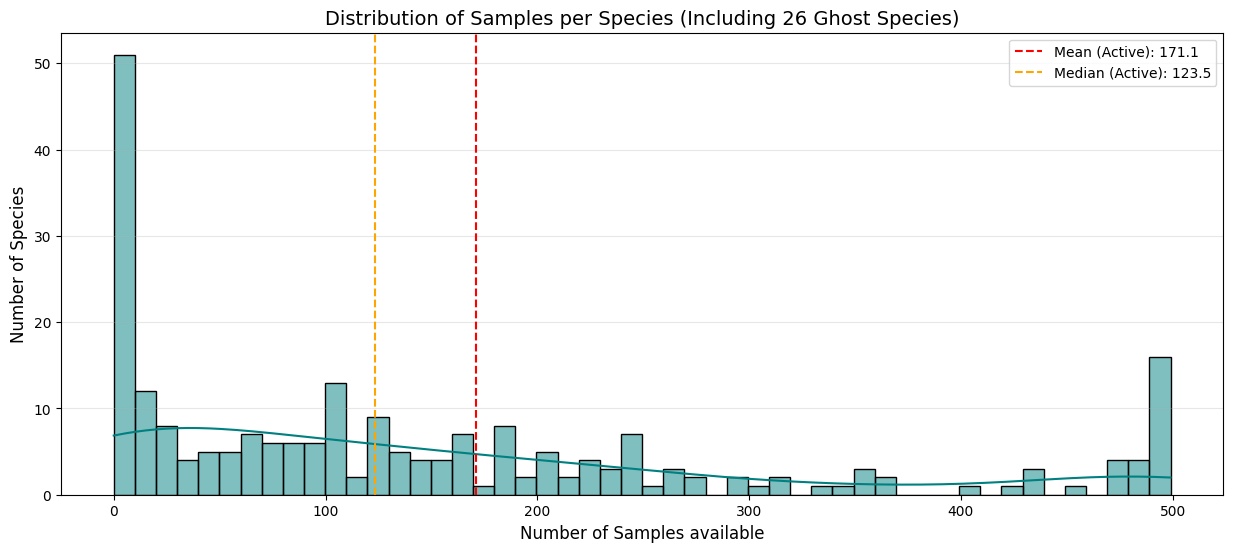


Danger Zone: There are 25 species with 1 to 9 recordings.
Ghost Zone: 26 species have 0 recordings.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
train_df = pd.read_csv('../../data/train.csv')
ss_labels = pd.read_csv('../../data/train_soundscapes_labels.csv')
taxonomy = pd.read_csv('../../data/taxonomy.csv')

# 2. Define the rescued and ghost species
rescued_species = ['517063', '1491113']
all_target_species = taxonomy['primary_label'].unique()

# 3. Calculate Counts
# Get counts from train_audio/ recordings
focal_counts = train_df['primary_label'].value_counts()

# Get counts for rescued species from Soundscapes
ss_counts = ss_labels[ss_labels['primary_label'].isin(rescued_species)]['primary_label'].value_counts()

# 4. Merge into a final Series containing all 234 species
# Start with Focal, add Soundscape counts, then fill missing targets with 0
final_counts = focal_counts.add(ss_counts, fill_value=0)

# Ensure all 234 species are present (even those with 0 counts)
final_counts = final_counts.reindex(all_target_species, fill_value=0).sort_values(ascending=False)

# 5. Print Statistics
print("=== FINAL SPECIES FREQUENCY STATISTICS (Focal + Soundscapes) ===")
print(f"Total target species monitored: {len(final_counts)}")
print(f"Species with >= 1 sample: {len(final_counts[final_counts > 0])}")
print(f"Species with 0 samples (Ghosts): {len(final_counts[final_counts == 0])}")
print("-" * 40)
print(f"Most recorded: {final_counts.index[0]} ({int(final_counts.iloc[0])} samples)")
print(f"Least recorded (non-zero): {final_counts[final_counts > 0].index[-1]} ({int(final_counts[final_counts > 0].iloc[-1])} samples)")

# 6. Plotting the Long Tail
plt.figure(figsize=(15, 6))

# Plotting distribution
# Note: We use a bar plot or hist of values. 
# Since we have many 0s, a histplot shows the distribution of "sample counts"
sns.histplot(final_counts.values, bins=50, kde=True, color='teal')

# Add vertical lines for Mean/Median of the species we actually have data for
active_counts = final_counts[final_counts > 0]
plt.axvline(active_counts.mean(), color='red', linestyle='--', label=f'Mean (Active): {active_counts.mean():.1f}')
plt.axvline(active_counts.median(), color='orange', linestyle='--', label=f'Median (Active): {active_counts.median():.1f}')

plt.title('Distribution of Samples per Species (Including 26 Ghost Species)', fontsize=14)
plt.xlabel('Number of Samples available', fontsize=12)
plt.ylabel('Number of Species', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 7. Zooming in on the "Danger Zone"
rarest_birds = final_counts[(final_counts > 0) & (final_counts < 10)]
print(f"\nDanger Zone: There are {len(rarest_birds)} species with 1 to 9 recordings.")
print(f"Ghost Zone: {len(final_counts[final_counts == 0])} species have 0 recordings.")

### Rating

/var/folders/my/27r6mb7d4sg2pyvcl7qgcf680000gn/T/ipykernel_96857/2876057376.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rated_audio, x='rating', palette='viridis')


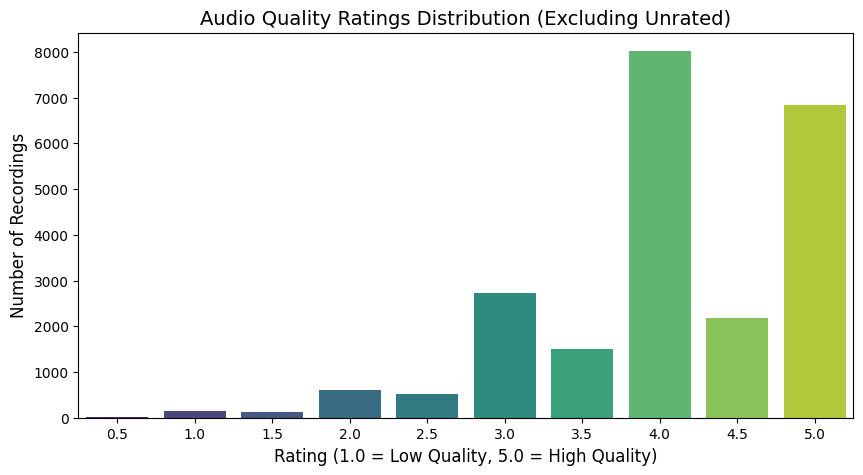


=== TOP 10 SPECIES WITH LOWEST AVERAGE AUDIO QUALITY ===
primary_label   rating
        41970 2.343750
      nacnig1 2.750000
       555145 2.750000
        22930 3.000000
        74580 3.000000
      blttit1 3.360294
      glteme1 3.451456
      ruftof1 3.526042
      ruther1 3.571429
      blheag1 3.590164

Number of recordings in train.csv: 35549
Number of recordings without ratings (rating = 0.0): 12849


In [8]:
# 1. Overall Rating Distribution
plt.figure(figsize=(10, 5))
# Filtering out 0.0 since it means unrated
rated_audio = train_df[train_df['rating'] > 0]

sns.countplot(data=rated_audio, x='rating', palette='viridis')
plt.title('Audio Quality Ratings Distribution (Excluding Unrated)', fontsize=14)
plt.xlabel('Rating (1.0 = Low Quality, 5.0 = High Quality)', fontsize=12)
plt.ylabel('Number of Recordings', fontsize=12)
plt.show()

# 2. Find the lowest quality species
# Group by species and calculate the mean rating
species_quality = rated_audio.groupby('primary_label')['rating'].mean().reset_index()

# Sort to find the lowest average quality
lowest_quality = species_quality.sort_values(by='rating').head(10)

print("\n=== TOP 10 SPECIES WITH LOWEST AVERAGE AUDIO QUALITY ===")
print(lowest_quality.to_string(index=False))

# Number of recordings without ratings (rating = 0.0)
unrated_count = train_df[train_df['rating'] == 0.0].shape[0]
print(f"\nNumber of recordings in train.csv: {train_df.shape[0]}")
print(f"Number of recordings without ratings (rating = 0.0): {unrated_count}")

### Duration

In [16]:
import librosa
from tqdm import tqdm

# Load metadata
train = pd.read_csv('../../data/train.csv')
base_path = '../../data/train_audio/'

def get_actual_duration(row):
    # Try the standard way first
    path = os.path.join(base_path, row['primary_label'], row['filename'])
    
    # Check if the file actually exists before trying to open it
    if not os.path.exists(path):
        # Alternative: Maybe filename already includes the label?
        path_alt = os.path.join(base_path, row['filename'])
        if os.path.exists(path_alt):
            path = path_alt
        else:
            return None # Mark as missing so we can audit later

    try:
        return librosa.get_duration(path=path)
    except Exception as e:
        return None

# Now apply with the fix
train['seconds'] = train.progress_apply(get_actual_duration, axis=1)

# Audit the failures
missing_files = train['seconds'].isna().sum()
print(f"Audit complete. Files not found or corrupted: {missing_files}")

100%|██████████| 35549/35549 [00:37<00:00, 935.63it/s] 

Audit complete. Files not found or corrupted: 0


In [18]:
# --- THE AUDIT ---
durations = train['seconds']

stats = {
    "Min": durations.min(),
    "Max": durations.max(),
    "Mean": durations.mean(),
    "Median": durations.median(),
    "Shorter than 5s": (durations < 5).sum(),
    "Longer than 5s": (durations >= 5).sum(),
    "Percentage Short": (durations < 5).sum() / len(durations) * 100
}

for k, v in stats.items():
    print(f"{k}: {v:.2f}")

Min: 0.01
Max: 6881.10
Mean: 34.88
Median: 21.00
Shorter than 5s: 2601.00
Longer than 5s: 32948.00
Percentage Short: 7.32


In [19]:
# Find the row with the shortest duration
min_row = train.loc[train['seconds'].idxmin()]
print("=== SHORTEST FILE ===")
print(f"Species: {min_row['primary_label']}")
print(f"Filename: {min_row['filename']}")
print(f"Duration: {min_row['seconds']}s")

# Find the row with the longest duration
max_row = train.loc[train['seconds'].idxmax()]
print("\n=== LONGEST FILE ===")
print(f"Species: {max_row['primary_label']}")
print(f"Filename: {max_row['filename']}")
print(f"Duration: {max_row['seconds']/60:.2f} minutes")

=== SHORTEST FILE ===
Species: redjun
Filename: redjun/iNat1681112.ogg
Duration: 0.008s

=== LONGEST FILE ===
Species: coffal1
Filename: coffal1/XC972702.ogg
Duration: 114.68 minutes
